In [1]:
from pathlib import Path

try:
  import google.colab
  IN_COLAB = True

  # Cell 1 (Colab only - skip locally)
  !git clone https://github.com/RealAshrafAhmed/waterloo-slt-reading-group.git /content/repo
  %cd /content/repo
  !pip install uv && uv sync --all-packages
  
  # Cell 2 (both environments)
  from colab_extensions.env import setup
  env = setup()
  ROOT, DATA, OUTPUTS = env["ROOT"], env["DATA"], env["OUTPUTS"]
except ImportError:
  IN_COLAB = False
  ROOT = Path.cwd().parents[1]
  basedir = Path(f"{ROOT}/outputs/mixture/poisson2d")
  datadir = Path(f"{basedir}/data")
  outputdir = Path(f"{basedir}/posterior")


if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using datadir={datadir}")
print(f"Using outputdir={outputdir}")

Using datadir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/data
Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior


In [2]:
# # Must be FIRST - before any other imports
# import os
# os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="

# import sys
# from pathlib import Path

# try:
#     import google.colab
#     IN_COLAB = True
# except ImportError:
#     IN_COLAB = False

# if IN_COLAB:
#   if Path("/content/drive").exists():
#     print("Nothing to initialize, driver is already mounted!")
#   else:
#     from google.colab import drive
#     drive.mount('/content/drive')
#     colab_dir = f"/content/drive/MyDrive/colab"
#     if colab_dir not in sys.path:
#       sys.path.insert(0, colab_dir)
#     from colab_setup import init
#     paths = init("singular-learning-theory")
#     print("Installing tex")
#     !apt-get install texlive-fonts-recommended texlive-latex-extra texlive-pictures dvipng

#   datadir = "/content/drive/MyDrive/colab/outputs/singular-learning-theory/mixtures/poisson2d"
# else:
#   from pathlib import Path
#   paths = {'repo': Path.cwd(), 'output': Path.cwd() / 'outputs'}
#   paths['output'].mkdir(exist_ok=True)
#   print("📍 Running locally")
#   from pathlib import Path

#   ROOT = Path.cwd().parents[1]
#   basedir = f"{ROOT}/outputs/mixture/poisson2d"
#   datadir = f"{basedir}/data"
#   outputdir = Path(f"{basedir}/posterior")


# if not outputdir.exists():
#   outputdir.mkdir(exist_ok=True)
#   print(f"Created {outputdir}!")

# print(f"Using datadir={datadir}")
# print(f"Using outputdir={outputdir}")

In [4]:
import pandas as pd

dgps_file = f"{datadir}/dgp.csv"
dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

,dsid,m0,m1,w0,w1
0,regular,15,1,0.75,0.25
1,e-singular,10,5,0.75,0.25
2,singular1,10,5,1.00,0.00
3,singular2,5,5,0.75,0.25


In [5]:
def find_truth_by_dsid(dsid: str):
    dgp = dgps.query(f"dsid=='{dsid}'")
    truth = dgp[["m0", "m1", "w0", "w1"]].iloc[0].tolist()
    return truth

In [7]:
from pymc_extensions.mixture.poisson import TemperedPoissonMixture
from tqdm.notebook import tqdm
import pymc as pm
import numpy as np
import arviz as az

n_components = 2
n_trials = 100

regimes = [50, 250, 5000]
# regimes = [50]

n_draws = 4000
n_tune = 10000
posterior_data = {}

for dsid in tqdm(dgps["dsid"].unique(), desc=f"class "):
  posterior_data[dsid] = {}
  for regime in tqdm(regimes, desc=f"dsid={dsid}, regime "):
    posterior_data_file = Path(f"{outputdir}/posterior-{dsid}-{regime}.nc")
    if posterior_data_file.exists(): # check if this data has already been generated
        idata = az.from_netcdf(posterior_data_file)
        print(f"Loaded posterior data from {posterior_data_file}!")
    else:
      dataset = pd.read_csv(f"{datadir}/{dsid}-{regime}.csv")
      X = dataset.iloc[:, 0].to_numpy()
      # Mixture of 2 Poisson variables
      with TemperedPoissonMixture(X=X, beta=1, mus_log_prior_sigma=2) as model:
        idata = model.sample(draws=n_draws, tune=n_tune)  # or "blackjax"
        idata.to_netcdf(posterior_data_file)
        print(f"File {posterior_data_file} created!.")
        
    posterior_data[dsid][regime]=idata

class :   0%|          | 0/4 [00:00<?, ?it/s]

dsid=regular, regime :   0%|          | 0/3 [00:00<?, ?it/s]

Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-regular-50.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-regular-250.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-regular-5000.nc!


dsid=e-singular, regime :   0%|          | 0/3 [00:00<?, ?it/s]

Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-e-singular-50.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-e-singular-250.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-e-singular-5000.nc!


dsid=singular1, regime :   0%|          | 0/3 [00:00<?, ?it/s]

Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular1-50.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular1-250.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular1-5000.nc!


dsid=singular2, regime :   0%|          | 0/3 [00:00<?, ?it/s]

Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular2-50.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular2-250.nc!
Loaded posterior data from /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson2d/posterior/posterior-singular2-5000.nc!


In [8]:
def chain_diag(dsid="singular1", regime=5000):
  az.plot_trace(posterior_data[dsid][regime], combined=True)

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot3d(dsid="singular1", regime=5000):
  idata = posterior_data[dsid][regime]
  w = idata.posterior["weights"][1,:,0]
  p0 = idata.posterior["mus"][1,:,0]
  p1 = idata.posterior["mus"][1,:,1]
  
  fig = plt.figure(figsize=(12, 10))  # width, height in inches
  ax = fig.add_subplot(111, projection='3d')
  
  n_chains = idata.posterior.dims["chain"]
  n_draws = idata.posterior.dims["draw"]
  markers = ['o', '^', '.', '+']
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain,:,0]
    p0 = idata.posterior["mus"][chain,:,0]
    p1 = idata.posterior["mus"][chain,:,1]
    ax.scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)

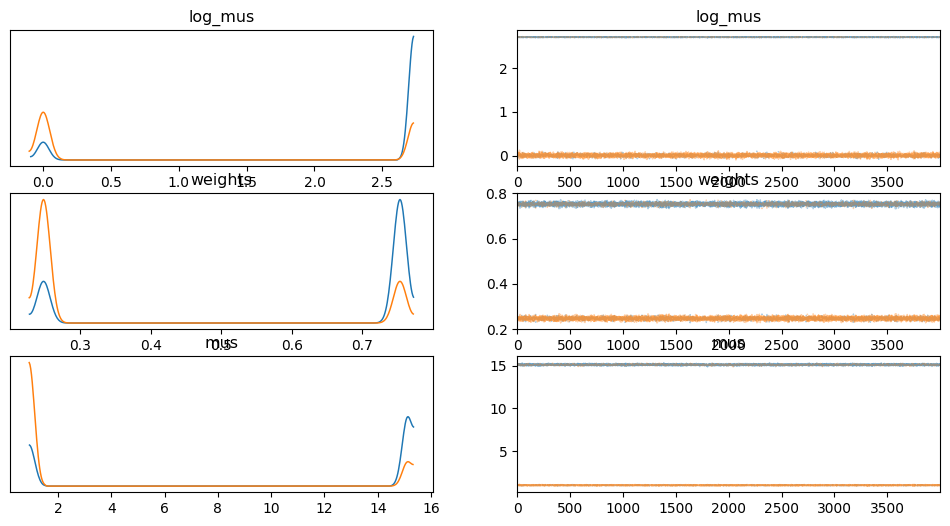

In [10]:
chain_diag("regular", 5000)

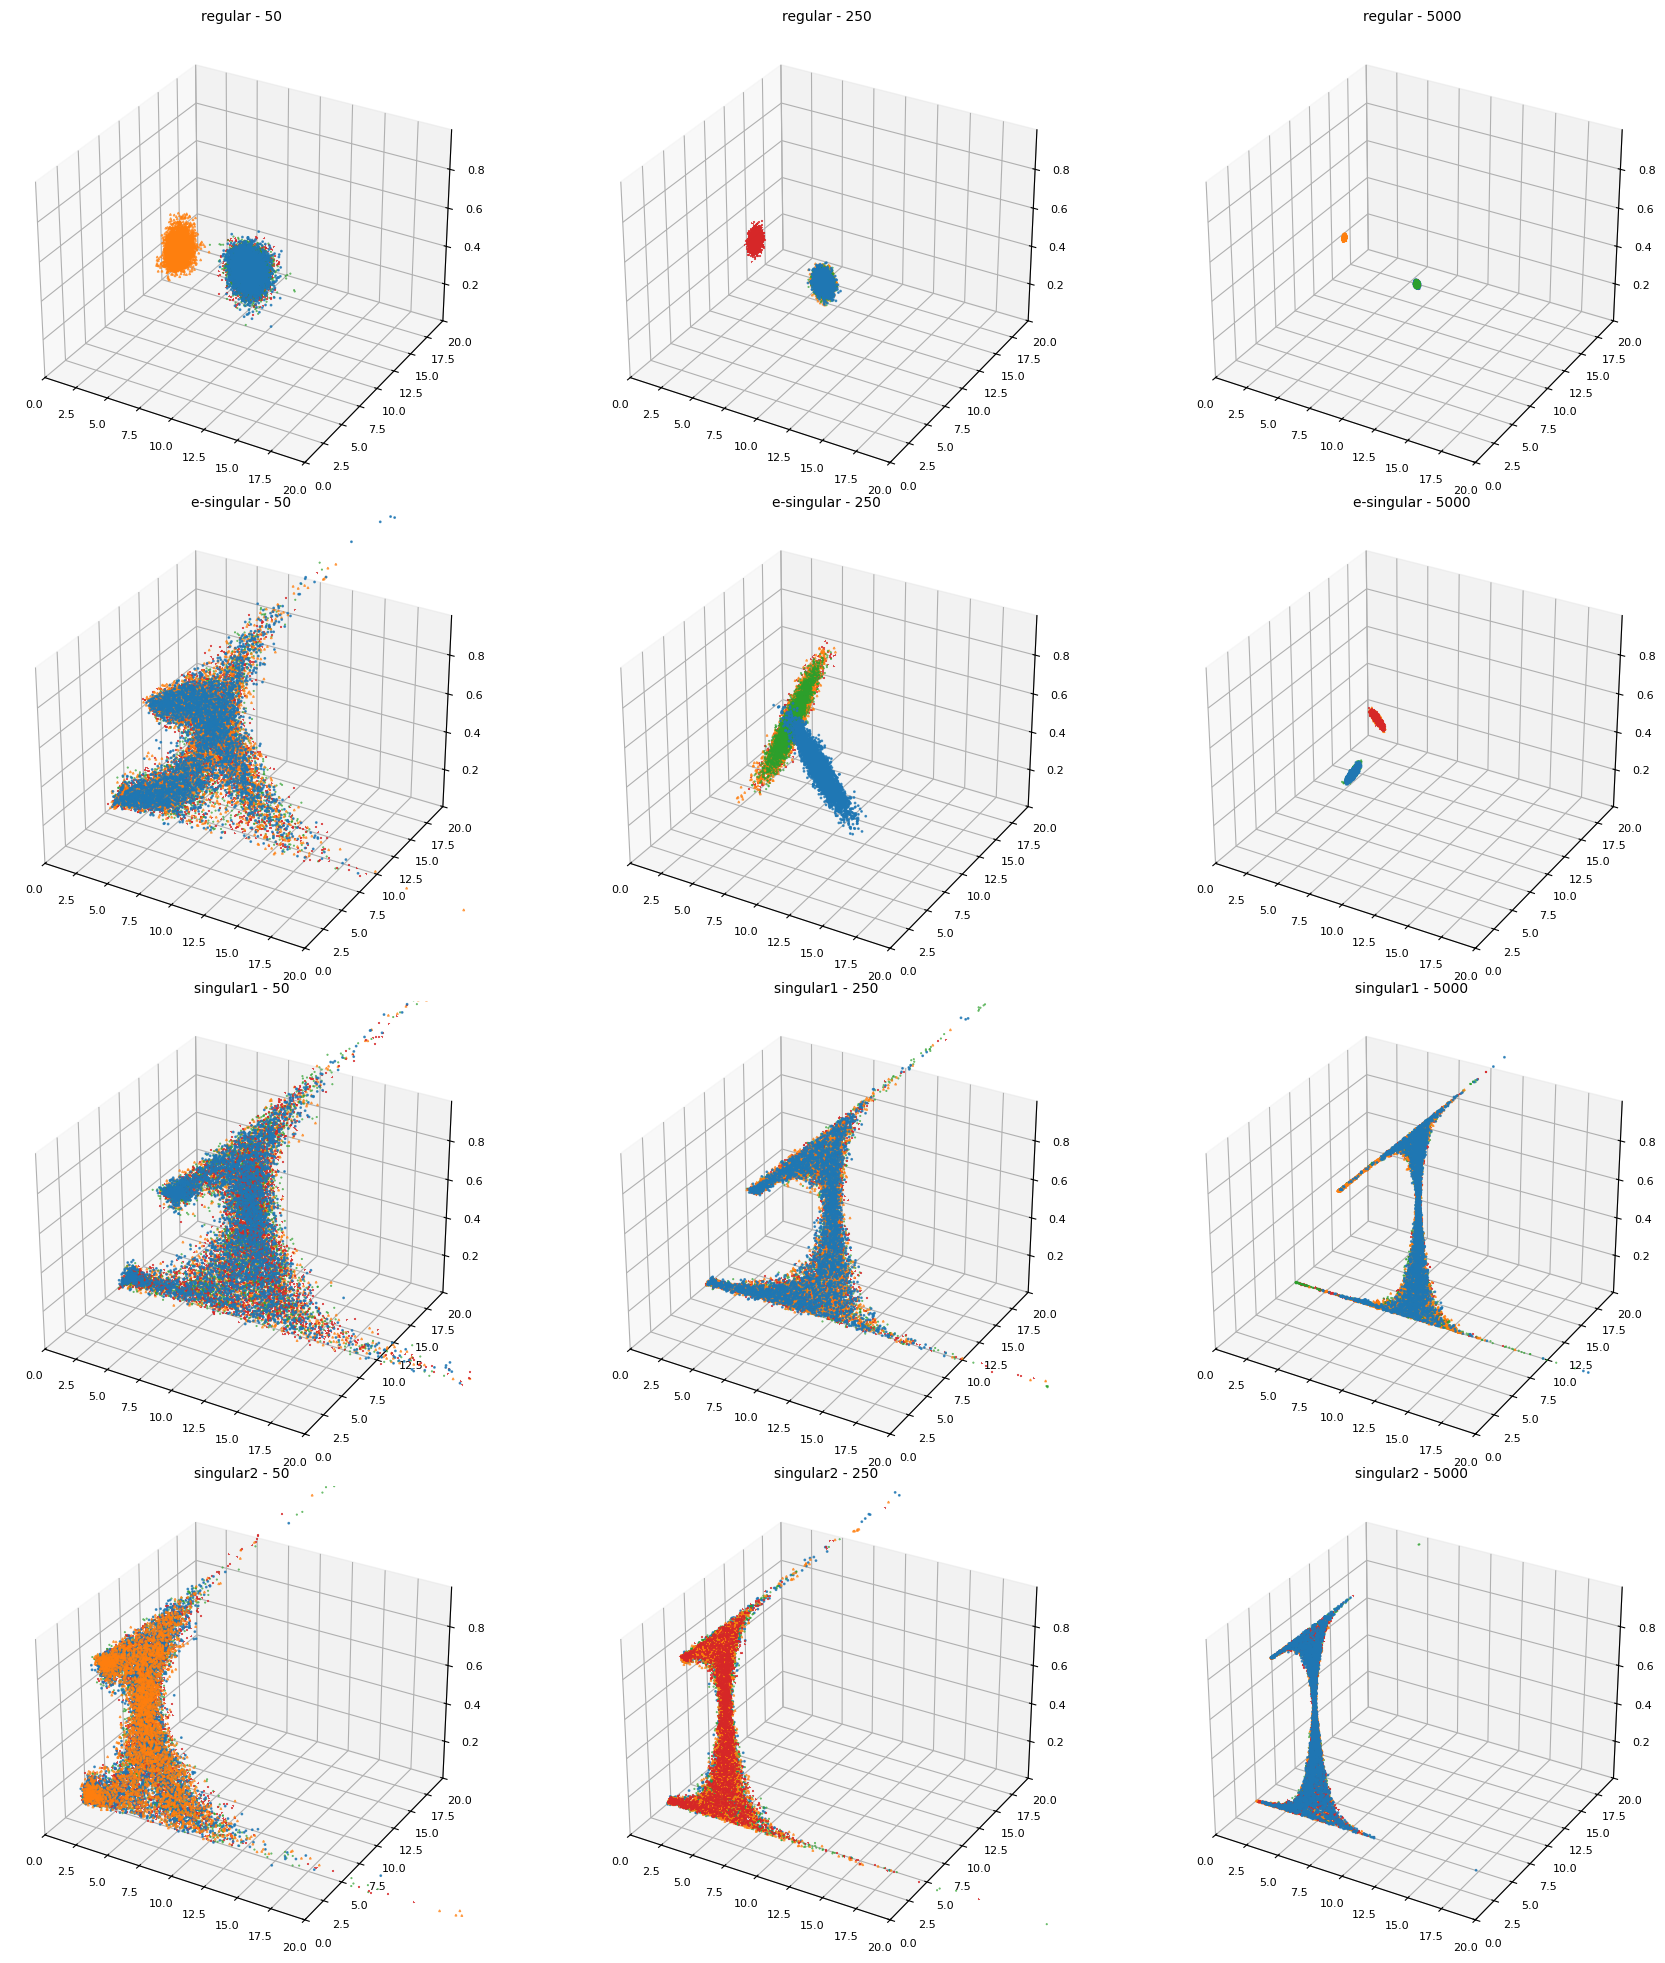

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 3, figsize=(18, 20), subplot_kw={'projection': '3d'})

# Reduce white space
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.98, top=0.98, bottom=0.02)

# First pass: collect global min/max for shared axes
all_p0, all_p1, all_w = [], [], []

for dsid, dsid_data in posterior_data.items():
    for regime, regime_data in dsid_data.items():
        idata = posterior_data[dsid][regime]
        for chain in range(idata.posterior.sizes["chain"]):
            all_p0.extend(idata.posterior["mus"][chain, :, 0].values)
            all_p1.extend(idata.posterior["mus"][chain, :, 1].values)
            all_w.extend(idata.posterior["weights"][chain, :, 0].values)

p0_lim = (np.min(all_p0), np.max(all_p0))
p1_lim = (np.min(all_p1), np.max(all_p1))
w_lim = (np.min(all_w), np.max(all_w))

# Second pass: plot with shared limits
i = 0
j = 0
markers = ['o', '^', '.', '+']

for dsid, dsid_data in posterior_data.items():
    for regime, regime_data in dsid_data.items():
        idata = posterior_data[dsid][regime]
        n_chains = idata.posterior.sizes["chain"]
        
        for chain in range(n_chains):
            w = idata.posterior["weights"][chain, :, 0]
            p0 = idata.posterior["mus"][chain, :, 0]
            p1 = idata.posterior["mus"][chain, :, 1]
            axes[i, j].scatter(p0, p1, w, marker=markers[chain], s=1, alpha=0.8)
        
        # Set shared limits
        axes[i, j].set_xlim(0,20)
        axes[i, j].set_ylim(0,20)
        axes[i, j].set_zlim(w_lim)
        
        # Optional: reduce tick label size to save space
        axes[i, j].tick_params(labelsize=8)
        
        # Optional: add title
        axes[i, j].set_title(f'{dsid} - {regime}', fontsize=10)
        
        j += 1
    i += 1
    j = 0

plt.show()

In [12]:
import plotly.graph_objects as go
import plotly.io as pio

def plot3dx(dsid="regular", regime=50):
  idata = posterior_data[dsid][regime]
  fig = go.Figure()
  
  markers = ['circle', 'diamond', 'square', 'cross']
  n_chains = idata.posterior.dims["chain"]
  
  for chain in range(n_chains):
    w = idata.posterior["weights"][chain, :, 0].values
    p0 = idata.posterior["mus"][chain, :, 0].values
    p1 = idata.posterior["mus"][chain, :, 1].values
    
    fig.add_trace(go.Scatter3d(
        x=p0, y=p1, z=w,
        mode='markers',
        marker=dict(size=1, symbol=markers[chain]),
        name=f'Chain {chain}'
    ))
  
  fig.update_layout(
      scene=dict(
          xaxis_title='m0',
          yaxis_title='m1',
          zaxis_title='w'
      )
  )
  
  # For Jupyter notebooks
  pio.renderers.default = "notebook"
  # or
  # pio.renderers.default = "iframe"
  # or for JupyterLab
  # pio.renderers.default = "jupyterlab"
  fig.update_layout(
      width=1000,
      height=800
  )
  fig.show()

In [13]:
# plot3dx("singular2", 5000)

In [18]:
# put the posteriors in a dataframe for easy visualization
joined_posterior_data = []
for dsid, dd in posterior_data.items():
    truth = find_truth_by_dsid(dsid=dsid)
    # dgp_weights = dgp[["w0", "w1"]].iloc[0].tolist()
    # dgp_mus = dgp[["m0", "m1"]].iloc[0].tolist()
    # truth = np.concatenate([dgp_mus, dgp_weights])
    for ss in regimes:
    # for trial in tqdm(range(dd[ss].shape[1]), desc=f"{dsid}-{ss} trials "):
        # for trial in tqdm(range(100), desc=f"{dsid}-{ss} trials "):
        # X = dd[ss].iloc[:, trial].to_numpy()
        # X = X.reshape(len(X), 1)
        # model._initialize_parameters(
            # X, rng
        # )  # cold reinitialization to force identifiability issues
        # model.fit(X)
        # mle, mle_detail = model.point_estimate()
        # fisher_mat = model.fisher_matrix(X)
      idata = dd[ss]
      param_samples = az.extract(idata, var_names=["weights", "mus"])
      n_draws = param_samples.sizes["sample"]
      joined_posterior_data.append({
        "w0": param_samples["weights"][0,].values,
        "m0": param_samples["mus"][0,].values,
        "m1": param_samples["mus"][1,].values,
        "n": np.repeat(ss, n_draws),
        "dsid": np.repeat(dsid, n_draws),
      })

joined_posterior_df = pd.concat([pd.DataFrame(d) for d in joined_posterior_data], ignore_index=True)
joined_posterior_df.head()

,w0,m0,m1,n,dsid
0,0.647353,14.656529,0.906479,50,regular
1,0.914756,15.136272,1.401210,50,regular
2,0.910784,14.399632,2.432348,50,regular
3,0.628496,15.983040,1.129834,50,regular
4,0.659319,15.773666,1.411289,50,regular


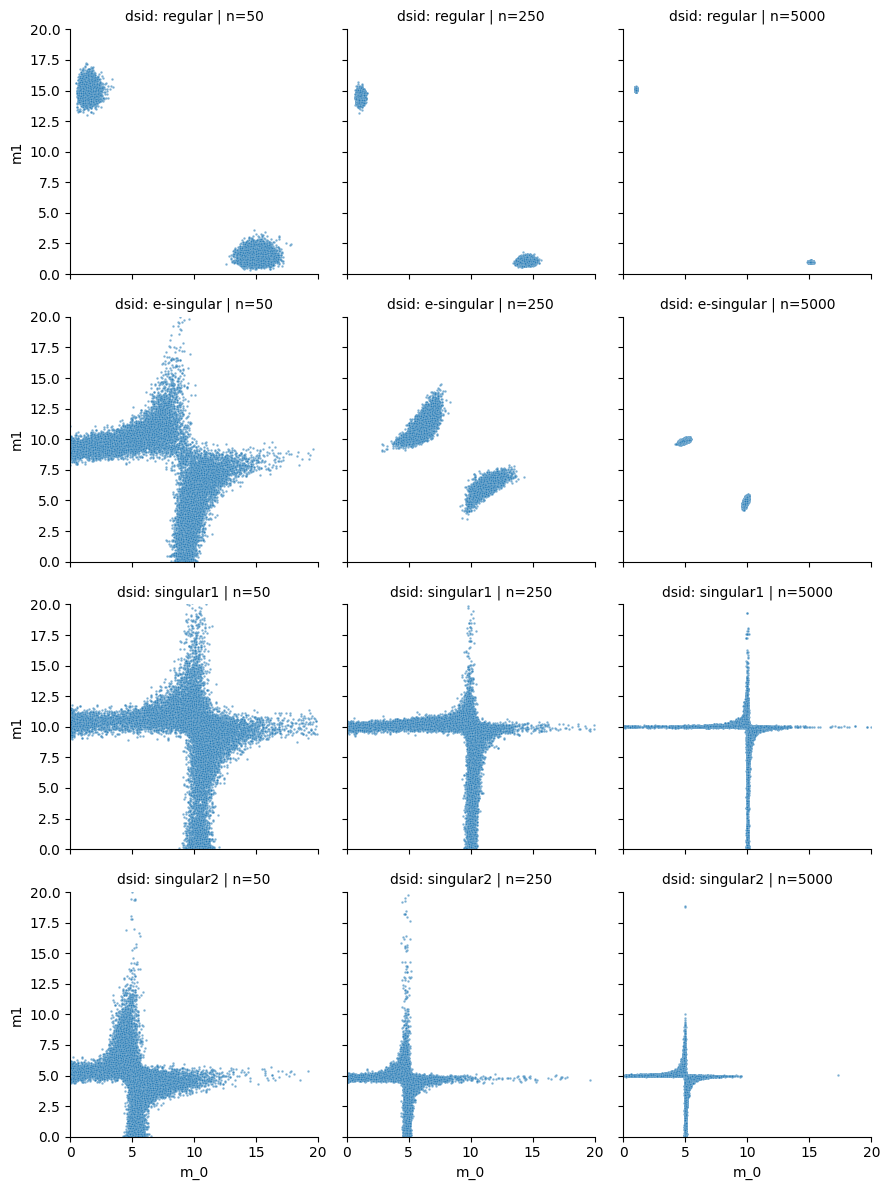

In [19]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m0", "m1", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 20))
# Add labels and formatting
g.set_axis_labels("m_0", "m1")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
plt.show()

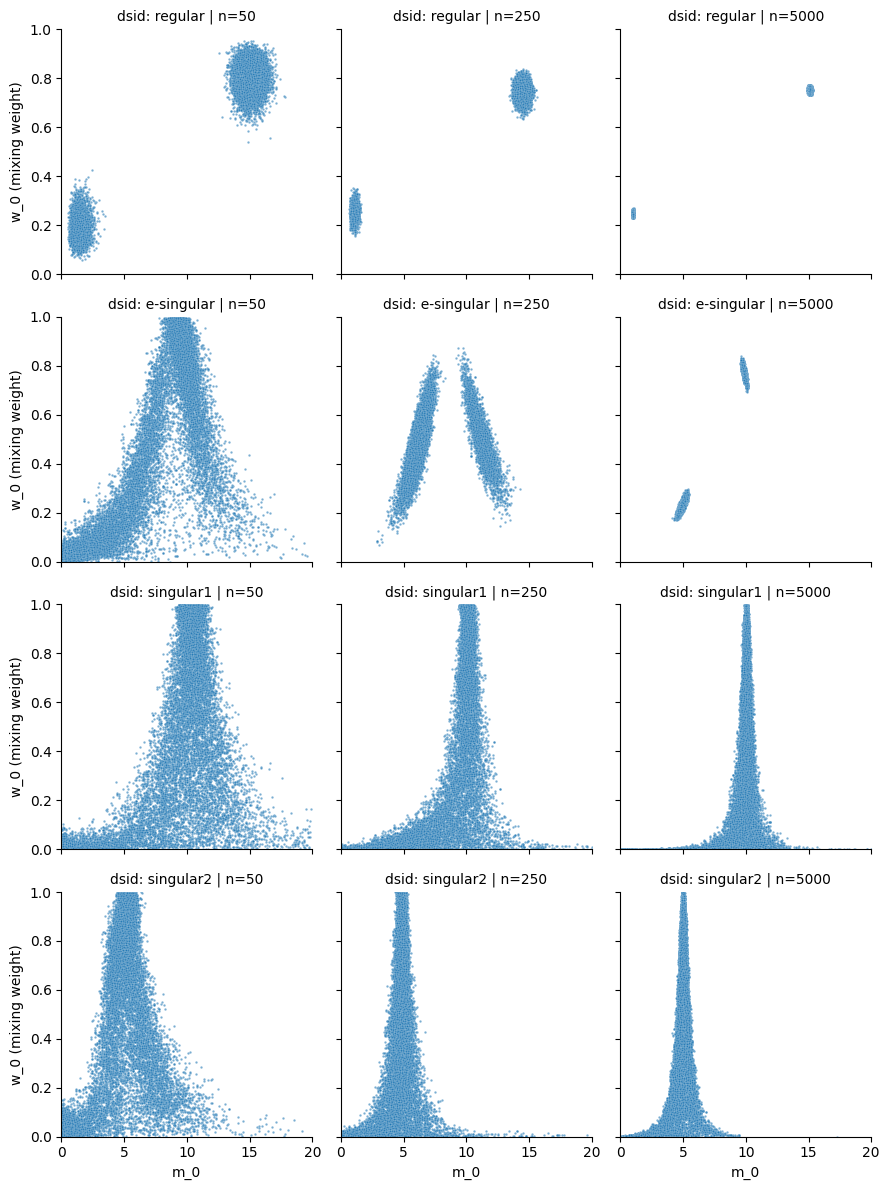

In [20]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m0", "w0", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 1))
# Add labels and formatting
g.set_axis_labels("m_0", "w_0 (mixing weight)")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
plt.show()

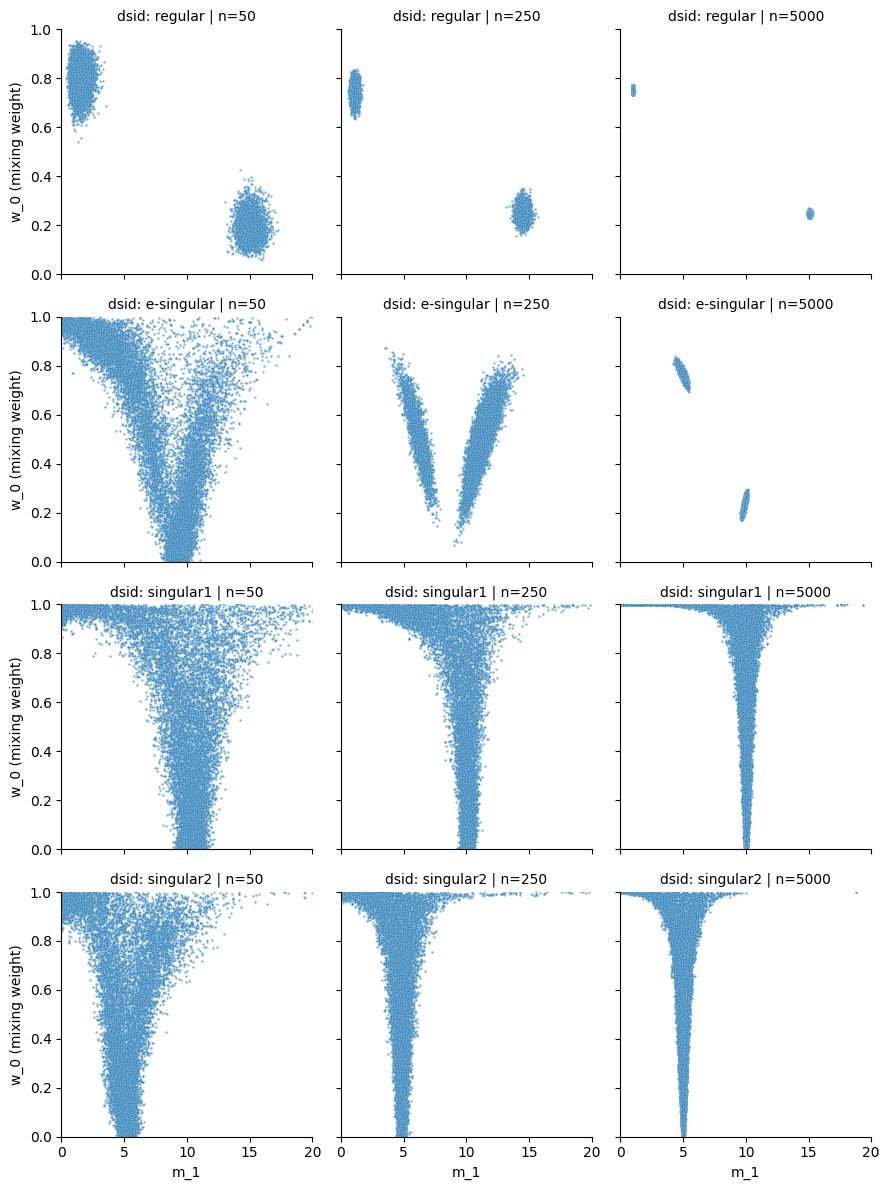

In [21]:
import seaborn as sns
# Create FacetGrid
g = sns.FacetGrid(joined_posterior_df, row="dsid", col="n", height=3, aspect=1)

# Map scatter plot
g.map(sns.scatterplot, "m1", "w0", alpha=0.6, s=3)

# Set axis limits
g.set(xlim=(0, 20), ylim=(0, 1))
# Add labels and formatting
g.set_axis_labels("m_1", "w_0 (mixing weight)")
g.set_titles(row_template="dsid: {row_name}", col_template="n={col_name}")

plt.tight_layout()
plt.show()

In [22]:
def clean_for_plotting(
    arr, method="percentile", threshold=1000, percentile=95, handle_nan=True, clip=True
):
    """
    Universal cleaning function for plotting

    Parameters:
    -----------
    arr : array-like
    method : 'percentile' or 'threshold'
        How to determine replacement values
    threshold : float
        For 'threshold' method: distance from min/max
    percentile : float
        For 'percentile' method: which percentile to use
    handle_nan : bool
        Whether to replace NaN
    clip : bool
        Whether to clip to [min, max] range
    """
    arr = np.asarray(arr, dtype=float).copy()

    finite_mask = np.isfinite(arr)

    if not np.any(finite_mask):
        return np.zeros_like(arr)

    finite_values = arr[finite_mask]

    if method == "percentile":
        low_val = np.percentile(finite_values, 100 - percentile)
        high_val = np.percentile(finite_values, percentile)
        value_range = high_val - low_val
        margin = max(value_range * 0.1, abs(high_val) * 0.01, 1.0)
        replacement_low = low_val - margin
        replacement_high = high_val + margin
    else:  # threshold
        finite_min = finite_values.min()
        finite_max = finite_values.max()
        replacement_low = finite_min - threshold
        replacement_high = finite_max + threshold

    # Replace infinities
    arr = np.where(np.isneginf(arr), replacement_low, arr)
    arr = np.where(np.isposinf(arr), replacement_high, arr)

    if handle_nan:
        arr = np.where(np.isnan(arr), replacement_high, arr)

    if clip:
        arr = np.clip(arr, replacement_low, replacement_high)

    return arr

In [ ]:
def plot_kl_contours(data_df, profile_kl, plot_options={}, profile_options={}):
    plot_options = {
        "quantiles": np.array(
            [
                0.01,
                0.02,
                0.03,
                0.04,
                0.05,
                0.075,
                0.9,
                0.1,
                0.2,
                0.3,
                0.4,
                0.5,
                0.6,
                0.7,
                0.8,
                0.9,
                0.99,
            ]
        ),
        # "colors": ['#808080', '#A0A0A0', '#C0C0C0'],
        "figsize": (16, 6),
        "linewidths": 2.0,
        "cmap": "magma",
        "line_colors": "black",
        "label_fontsize": 1000,
    } | plot_options

    profile_options = {"grid_size": 100} | profile_options

    # Get unique values for facets
    dsids = data_df["dsid"].unique()
    n_obs_list = sorted(data_df["n"].unique())

    n_rows = len(dsids)
    n_cols = len(n_obs_list)

    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10), sharex=True, sharey=True)

    # Plot each panel
    for i, dsid in enumerate(tqdm(dsids, desc=f"datasets ")):
        # for i, dsid in enumerate(dsids):
        dgp = dgps.query(f"dsid=='{dsid}'")
        truth = dgp[["p0", "p1", "w0", "w1"]].iloc[0].tolist()
        height = profile_kl(
            n_components=n_components,
            n_trials=n_trials,
            truth=truth,
            x_param={"name": "probs", "index": 0},
            y_param={"name": "probs", "index": 1},
            profile_grid_size=profile_options["grid_size"],
        )

        for j, n in enumerate(tqdm(sample_sizes, desc=f"{dsid} figures")):
            ax = axes[i, j]

            # Filter data for this combination
            subset = mles_df[(mles_df["dsid"] == dsid) & (mles_df["n"] == n)]

            # 1. computed profile KL values
            x = np.linspace(0, 1, 50)
            y = np.linspace(0, 1, 50)
            X, Y = np.meshgrid(x, y)
            Z = height(X, Y)

            # compoute contour levels for the quantiles
            # Z = clean_for_plotting(height(X,Y), method='percentile', percentile=0.999)
            levels = np.unique(np.quantile(Z, plot_options["quantiles"]))

            # align contours with levels
            n_levels = len(levels)
            cmap = plt.get_cmap("YlOrRd")
            colors = [cmap(q) for q in np.linspace(0, 1, n_levels)]

            cs = ax.contourf(
                X, Y, Z, levels=levels, colors=colors, alpha=0.8, extend="both"
            )
            cs_lines = ax.contour(X, Y, Z, levels=levels, colors="black", linewidths=1)
            # Create a dictionary mapping each level to its corresponding quantile value
            fmt = {}
            for l, level in enumerate(levels):
                if l < len(plot_options["quantiles"]):
                    # Just show the quantile value (e.g., "0.95")
                    fmt[level] = f"{plot_options['quantiles'][l]:.2f}"

            # Apply the custom labels
            ax.clabel(
                cs_lines,
                fontsize=6,
                inline=True,
                fmt=fmt,
                inline_spacing=10,
                colors="black",
                use_clabeltext=True,
            )

            # Scatter plot
            sns.scatterplot(data=subset, x="p0", y="p1", ax=ax, alpha=1, s=5)

            # Add title
            if i == 0:
                ax.set_title(f"n={n}", fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"dsid: {dsid}\np_0", fontweight="bold")
            else:
                ax.set_ylabel("p_1")

            if i == n_rows - 1:
                ax.set_xlabel("p_0")
            else:
                ax.set_xlabel("")
            # break
        # break
    return fig, axes


fig, axes = plot_kl_contours(
    mles_df, profile_kl=create_mixbinom_profile_kl, profile_options={"grid_size": 20}
)

plt.tight_layout()
fig.savefig(Path(f"{basedir}/mle/mles_with_kl.png"), dpi=600, bbox_inches="tight")
plt.show()